# Hungary: EU Fiscal Rules Targets from 2026

This notebook estimates the structural primary balance (SPB) and overall balance that Hungary would have to reach under the EU fiscal rules, using the Commission's DSA methodology (Debt Sustainability Monitor, Annexes A3 and A4) and the rules of the reformed EU fiscal framework, for adjustment periods of **4 and 7 years** starting from **2026**, with and without the EDP and the safeguards.

Context: joining the euro requires the absence of an excessive deficit procedure, not only a deficit below 3% of GDP. Under the 2024 fiscal framework, the DSA determines the SPB target; in the Commission's 2024 guidance, this target was above 3% of GDP for Hungary.

**Data**: the latest input workbook (Commission spring 2026 forecast via AMECO for 2026 and 2027, ECB, Ageing Report, see the workbook's `Sources` sheet), with Bloomberg market data of July 2026, which reflect the decline in interest rates after the April 2026 elections.

**How to use**: all inputs are in section 1. By default, the 2026 fiscal figures are those of the Commission forecast; set your own 2026 projection there if needed. Run all cells. The inputs are passed to the model as `overrides` on top of the input workbook (no files are changed). To update the public data first, run `build_inputs(mode='api')` (section 1 of `tutorial.ipynb`).

Section 3 shows the targets under the EU fiscal rules, section 4 the targets with the simplified implementation of the Commission prior guidance sheets, and section 5 the Commission's 2024 guidance for Hungary.

For comments and suggestions please contact lennard.welslau[at]gmail[dot]com.\
Last update: September 2026

In [1]:
# Import libraries and modules
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid': True, 'grid.color': 'black', 'grid.alpha': 0.25, 'grid.linestyle': '--', 'font.size': 12})
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# Import the DSA model classes and data functions from the code folder
sys.path.append(os.path.abspath('..'))
from classes import StochasticDsaModel as DSA
from data_pipeline import latest_input_file, read_country
from data_pipeline.commission import load_prior_guidance

# Set autoreload
%load_ext autoreload
%autoreload 2

## 1. Inputs

**2026 projection** (% of GDP). `None` keeps the Commission spring 2026 forecast. If you set the overall balance only, the other figures are derived consistently: the primary balance keeps the forecast's interest expenditure, the SPB keeps the forecast's difference between SPB and primary balance (cyclical component and one-offs), and the debt ratio increases by the deficit above the forecast. The 2027 forecast is shifted by the same amounts, so that the forecast changes from 2026 to 2027 are kept.

**Market data from Bloomberg** (July 2026). Market expectations are not publicly available; by default, the input workbook takes them from the Commission prior guidance sheet (for Hungary: the updated 2024 guidance). Set a value to `None` to keep the workbook value.

| Bloomberg field | Model input | Use |
|---|---|---|
| `RATE_3M`, `RATE_10Y` | `INTEREST_RATE_ST`, `INTEREST_RATE_LT` in 2026 | Short- and long-term market rates in T |
| `FWD_RATE_3M10Y` | `INTEREST_RATE_ST_T10` | 3-month rate 10 years ahead (T+10 anchor) |
| `FWD_RATE_10Y10Y` | `INTEREST_RATE_LT_T10` | 10-year rate 10 years ahead (T+10 anchor) |
| `FWD_INFL_5Y5Y` | `INFLATION_T10` | Euro area 5y5y inflation swap. For Hungary, the Commission adds half of the spread between Hungarian and euro area GDP deflator inflation in the last forecast year |

Between these anchors, the model interpolates linearly; from T+10, rates and inflation converge to the T+30 values of the workbook (Hungary: long-term rate 5%, inflation 3%).

In [2]:
COUNTRY = 'HUN'

# 2026 projection (% of GDP); None: Commission spring 2026 forecast
FISCAL_BALANCE_2026 = None               # overall balance
PRIMARY_BALANCE_2026 = None              # None: overall balance plus forecast interest expenditure
STRUCTURAL_PRIMARY_BALANCE_2026 = None   # None: primary balance plus the forecast's SPB-PB difference
DEBT_RATIO_2026 = None                   # None: forecast debt ratio plus the deficit above the forecast

# Bloomberg data, July 2026 (% p.a.); None: value of the input workbook
BBG = {
    'RATE_3M': 5.567708333,
    'RATE_10Y': 5.24325,
    'FWD_RATE_3M10Y': 5.225197083,
    'FWD_RATE_10Y10Y': 5.311734583,
    'FWD_INFL_5Y5Y': 2.12155,
}

## 2. Model inputs

The inputs of section 1 are passed to the model as `overrides`: rows with the input code (see the `Sources` sheet of the input workbook), the year (none for parameters) and the value. The table compares them with the input workbook.

In [3]:
series, params = read_country(latest_input_file(), COUNTRY)
T = int(params['REFERENCE_YEAR'])            # reference year (2026)
L = int(params['LAST_FORECAST_YEAR'])        # last forecast year (2027)
overrides = []

# 2026 projection, derived consistently where not given, and 2027 shifted by the 2026 revisions
fc = series.loc[T]
ob = fc['FISCAL_BALANCE'] if FISCAL_BALANCE_2026 is None else FISCAL_BALANCE_2026
pb = PRIMARY_BALANCE_2026 if PRIMARY_BALANCE_2026 is not None else ob + fc['PRIMARY_BALANCE'] - fc['FISCAL_BALANCE']
spb = (STRUCTURAL_PRIMARY_BALANCE_2026 if STRUCTURAL_PRIMARY_BALANCE_2026 is not None
       else pb + fc['STRUCTURAL_PRIMARY_BALANCE'] - fc['PRIMARY_BALANCE'])
d = DEBT_RATIO_2026 if DEBT_RATIO_2026 is not None else fc['DEBT_RATIO'] + fc['FISCAL_BALANCE'] - ob
revisions = {'FISCAL_BALANCE': ob - fc['FISCAL_BALANCE'], 'PRIMARY_BALANCE': pb - fc['PRIMARY_BALANCE'],
             'STRUCTURAL_PRIMARY_BALANCE': spb - fc['STRUCTURAL_PRIMARY_BALANCE'], 'DEBT_RATIO': d - fc['DEBT_RATIO']}
if any(abs(v) > 1e-9 for v in revisions.values()):
    for year in range(T, L + 1):
        for code, revision in revisions.items():
            overrides.append({'CODE': code, 'YEAR': year, 'VALUE': series.loc[year, code] + revision})
        overrides.append({'CODE': 'DEBT_TOTAL', 'YEAR': year,
                          'VALUE': (series.loc[year, 'DEBT_RATIO'] + revisions['DEBT_RATIO']) / 100 * series.loc[year, 'NOMINAL_GDP']})

# Bloomberg market data
spread = series.loc[L, 'GDP_DEFLATOR_PCH'] - series.loc[L, 'EA_GDP_DEFLATOR_PCH']
market = [('INTEREST_RATE_ST', T, BBG['RATE_3M']),
          ('INTEREST_RATE_LT', T, BBG['RATE_10Y']),
          ('INTEREST_RATE_ST_T10', None, BBG['FWD_RATE_3M10Y']),
          ('INTEREST_RATE_LT_T10', None, BBG['FWD_RATE_10Y10Y']),
          ('INFLATION_T10', None, None if BBG['FWD_INFL_5Y5Y'] is None else BBG['FWD_INFL_5Y5Y'] + spread / 2)]
overrides += [{'CODE': code, 'YEAR': year, 'VALUE': value} for code, year, value in market if value is not None]

# Comparison with the input workbook
table = pd.DataFrame(overrides)
table['YEAR'] = table['YEAR'].apply(lambda y: 'parameter' if pd.isna(y) else int(y))
table['Input workbook'] = [params[r.CODE] if r.YEAR == 'parameter' else series.loc[r.YEAR, r.CODE] for r in table.itertuples()]
table = table.rename(columns={'CODE': 'Input', 'YEAR': 'Year', 'VALUE': 'Model input'}).set_index(['Input', 'Year'])
table[['Input workbook', 'Model input']].style.format('{:,.2f}')

,,Input workbook,Model input
Input,Year,,
INTEREST_RATE_ST,2026,5.73,5.57
INTEREST_RATE_LT,2026,6.03,5.24
INTEREST_RATE_ST_T10,parameter,6.50,5.23
INTEREST_RATE_LT_T10,parameter,6.93,5.31
INFLATION_T10,parameter,2.99,2.43


## 3. SPB and overall balance targets under the EU fiscal rules

We run `find_spb_binding` for 4- and 7-year adjustment periods starting in 2027 (the year after T), in three versions:
- **DSA only**: the DSA criteria (debt declines, or stays below 60%, over 10 years after the adjustment period in the deterministic scenarios and with 70% probability in the stochastic projection; deficit below 3%), without EDP and safeguards
- **DSA and EDP**: plus the minimum adjustment of 0.5% of GDP per year while the deficit exceeds 3% (in SPB terms until 2027, in structural balance terms from 2028)
- **DSA, EDP and safeguards**: plus the debt sustainability safeguard (average debt decline of 0.5 pp. per year while debt is between 60% and 90%, from the year the EDP is projected to be abrogated) and the deficit resilience safeguard (minimum annual adjustment of 0.4 pp., or 0.25 pp. for a 7-year period, until the structural deficit is below 1.5%)

The model applies the default rules (Darvas, Welslau and Zettelmeyer, 2024), which translate the legal texts of the reformed framework consistently across countries and allow front-loading of the adjustment, with the default model settings (fiscal multiplier of 0.75 with a persistent effect on the output gap).

The table shows the SPB at the end of the adjustment period and the implied overall and structural balance, the binding criterion, and the year in which the EDP is projected to be abrogated (the first year with a deficit below 3% in that and the previous year). Where the DSA requires more adjustment than the EDP and the safeguards, the three versions give the same result.

In [4]:
versions = {
    'DSA only': dict(edp=False, debt_safeguard=False, deficit_resilience=False),
    'DSA and EDP': dict(debt_safeguard=False, deficit_resilience=False),
    'DSA, EDP and safeguards': dict(),
}


def run_rules(rules=None, **model_params):
    """
    Run find_spb_binding for 4- and 7-year adjustment periods and the three versions. Returns (models, summary table).
    """
    models, results = {}, {}
    for n in [4, 7]:
        for version, options in versions.items():
            model = DSA(COUNTRY, adjustment_period=n, overrides=overrides, **model_params)
            np.random.seed(0)
            model.find_spb_binding(rules=rules, print_results=False, **options)
            models[(n, version)] = model
            s, e = model.adjustment_start, model.adjustment_end
            results[(f'{n}-year', version)] = {
                f'SPB {T} (% of GDP)': model.spb_bca[s - 1],
                'SPB at end of adjustment (% of GDP)': model.spb_bca[e],
                'Average annual adjustment (pp.)': (model.spb_bca[e] - model.spb_bca[s - 1]) / n,
                'Overall balance at end of adjustment (% of GDP)': model.ob[e],
                'Structural balance at end of adjustment (% of GDP)': model.sb[e],
                'Debt at end of adjustment (% of GDP)': model.d[e],
                'Debt 10 years after adjustment (% of GDP)': model.d[e + 10],
                'Binding criterion': model.binding_tables['Summary'].iloc[:, 0]['Binding criterion'],
                'EDP abrogation year (projected)': model.edp_abrogation_year() if options.get('edp', True) else None,
            }
    summary = pd.DataFrame(results).T
    summary.index.names = ['Adjustment period', 'Rules applied']
    return models, summary


models, summary = run_rules()
summary.style.format(precision=2, na_rep='-')

Adjustment paths under the full rules (DSA, EDP and safeguards): annual SPB steps, minimum steps under the EDP and the deficit resilience safeguard, balances and debt.

In [5]:
for n in [4, 7]:
    print(f'{n}-year adjustment period, DSA, EDP and safeguards')
    display(models[(n, 'DSA, EDP and safeguards')].binding_tables['Adjustment path'].loc[:T + n + 5]
            .style.format(precision=2, na_rep=''))

4-year adjustment period, DSA, EDP and safeguards


,Annual SPB adjustment (pp.),EDP minimum step (pp.),SPB before change in ageing costs (% of GDP),Structural primary balance (% of GDP),Overall balance (% of GDP),Structural balance (% of GDP),Debt (% of GDP),Net expenditure growth (%)
Year,,,,,,,,
2026,,,-2.01,-2.01,-6.16,-5.90,75.05,
2027,1.28,0.50,-0.73,-0.73,-4.84,-4.45,77.05,1.48
2028,1.28,1.28,0.56,0.56,-3.96,-3.28,78.31,1.46
2029,1.28,,1.84,1.84,-2.89,-2.05,78.21,1.45
2030,1.28,,3.13,3.13,-1.60,-0.76,76.59,1.43
2031,0.00,,3.13,3.03,-1.18,-0.74,73.95,4.28
2032,0.00,,3.13,2.91,-0.89,-0.75,71.35,4.26
2033,0.00,,3.13,2.76,-0.78,-0.78,68.99,4.25
2034,0.00,,3.13,2.59,-0.85,-0.85,67.03,4.23


7-year adjustment period, DSA, EDP and safeguards


,Annual SPB adjustment (pp.),EDP minimum step (pp.),SPB before change in ageing costs (% of GDP),Structural primary balance (% of GDP),Overall balance (% of GDP),Structural balance (% of GDP),Debt (% of GDP),Net expenditure growth (%)
Year,,,,,,,,
2026,,,-2.01,-2.01,-6.16,-5.90,75.05,
2027,0.79,0.50,-1.22,-1.22,-5.15,-4.93,77.10,2.58
2028,0.79,0.79,-0.43,-0.43,-4.66,-4.26,78.86,2.56
2029,0.79,0.79,0.36,0.36,-4.06,-3.55,79.81,2.55
2030,0.79,0.79,1.15,1.15,-3.32,-2.81,79.85,2.53
2031,0.79,,1.94,1.94,-2.57,-2.03,79.17,2.51
2032,0.79,,2.73,2.73,-1.75,-1.21,77.67,2.50
2033,0.79,,3.52,3.52,-0.88,-0.35,75.38,2.48
2034,0.00,,3.52,3.35,-0.66,-0.39,72.53,4.23


SPB, overall balance and debt under the full rules, and under no policy change (SPB constant at its 2026 level) for comparison.

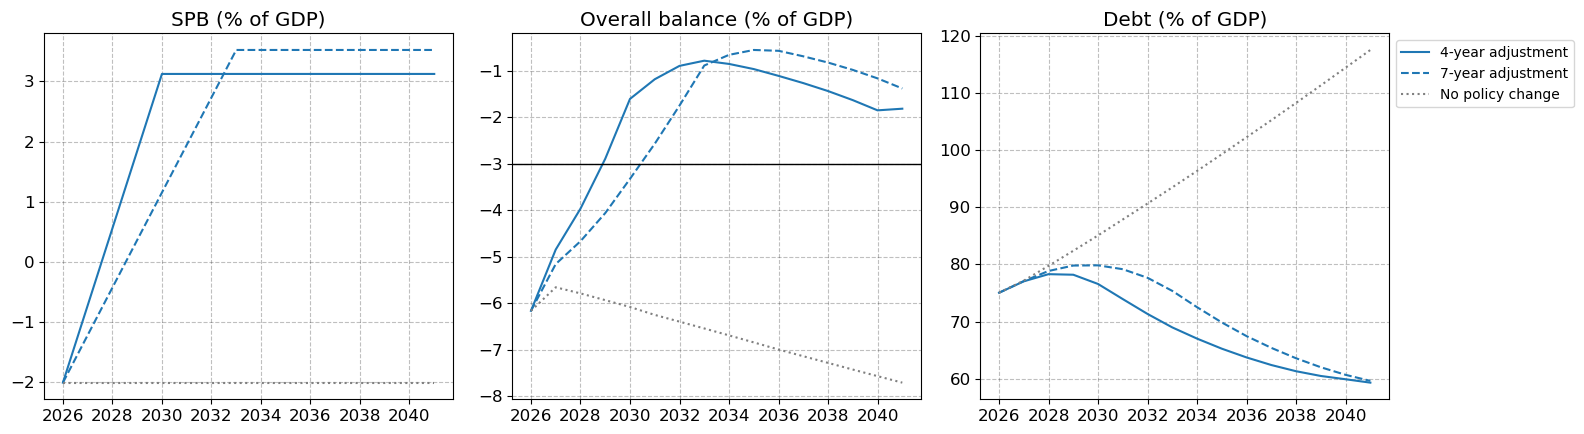

In [6]:
npc = DSA(COUNTRY, overrides=overrides)
npc.project()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
paths = [(models[(4, 'DSA, EDP and safeguards')], '4-year adjustment', '-'),
         (models[(7, 'DSA, EDP and safeguards')], '7-year adjustment', '--'),
         (npc, 'No policy change', ':')]
for m, label, ls in paths:
    years = np.arange(m.start_year, m.start_year + 16)
    for ax, var in zip(axes, ['spb_bca', 'ob', 'd']):
        ax.plot(years, getattr(m, var)[:16], ls=ls, color='tab:blue' if ls != ':' else 'grey', label=label)
for ax, title in zip(axes, ['SPB (% of GDP)', 'Overall balance (% of GDP)', 'Debt (% of GDP)']):
    ax.set_title(title)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[1].axhline(-3, color='black', lw=1)
axes[2].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.tight_layout()
plt.show()

## 4. Commission prior guidance implementation

For comparison, the same runs with the implementation of the Commission prior guidance calculation sheets (`rules='commission'`) and the Commission's model settings (output gap closure rule for the fiscal multiplier, `fiscal_multiplier_type='ec'`, with a multiplier of 0.6 as in the sheets issued from 2025).

Differences to section 3 arise from the simplified implementation of the rules in the Commission sheets, not from different data:
- **Constant annual adjustment**: the Commission sheets assume the same SPB step in every year; EDP and deficit resilience minimum steps are added on top where they bind. The default rules front-load the adjustment where minimum steps bind and reduce later steps, so that the SPB target is unchanged.
- **DSA criteria**: the Commission requires debt to decline in all scenarios (or to be below 60% in all scenarios) rather than per scenario, and rounds the annual adjustment up to 0.01 pp.
- **Debt safeguard**: assessed on debt bands at the start of each year over the adjustment years outside the EDP, rather than as the average decline from the year the EDP is projected to be abrogated.
- **Fiscal multiplier**: the output gap closure rule of the sheets with a multiplier of 0.6, instead of a persistent effect with a multiplier of 0.75.

See section 4 of `tutorial.ipynb` for a detailed comparison of the rules.

In [7]:
models_commission, summary_commission = run_rules(rules='commission', fiscal_multiplier=0.6, fiscal_multiplier_type='ec')

# SPB and overall balance at the end of the adjustment period: default rules and Commission implementation
cols = ['SPB at end of adjustment (% of GDP)', 'Overall balance at end of adjustment (% of GDP)', 'Binding criterion']
pd.concat({'Default rules': summary[cols], 'Commission implementation': summary_commission[cols]}, axis=1).style.format(precision=2)

## 5. Comparison with the Commission's prior guidance for Hungary

For reference: the Commission's prior guidance for Hungary (2024 guidance and the updated guidance, both with reference year 2024 and adjustment from 2025) and the model with the Commission's own inputs from the calculation sheets. Differences to sections 3 and 4 reflect the new starting position in 2026, the later adjustment period, and updated forecasts and market data.

The model reproduces the 2024 guidance closely. The updated guidance requires a higher SPB than the model with the inputs of the updated sheet; the published sheet does not explain the difference (see `commission_replication.ipynb`).

In [8]:
rows = {}
for vintage, file in [('2024', 'dsa_inputs_commission_2024.xlsx'), ('latest', 'dsa_inputs_commission_latest.xlsx')]:
    guidance = load_prior_guidance([COUNTRY], vintage=vintage)[COUNTRY].results()
    for n in [4, 7]:
        m = DSA(COUNTRY, adjustment_period=n, input_file=file)
        np.random.seed(0)
        m.find_spb_binding(rules='commission', print_results=False)
        rows[('2024 guidance' if vintage == '2024' else 'Updated guidance', f'{n}-year')] = {
            'Commission: SPB at end of adjustment': guidance[f'spb_end_{n}y'],
            'Model with Commission inputs: SPB at end of adjustment': m.spb_bca[m.adjustment_end],
            'Model with Commission inputs: overall balance at end of adjustment': m.ob[m.adjustment_end],
        }
pd.DataFrame(rows).T.round(2)

Commission: SPB at end of adjustment  \
2024 guidance    4-year                                  2.67   
                 7-year                                  3.31   
Updated guidance 4-year                                  3.44   
                 7-year                                  3.84   

                         Model with Commission inputs: SPB at end of adjustment  \
2024 guidance    4-year                                               2.67        
                 7-year                                               3.27        
Updated guidance 4-year                                               2.76        
                 7-year                                               3.29        

                         Model with Commission inputs: overall balance at end of adjustment  
2024 guidance    4-year                                              -2.19                   
                 7-year                                              -1.27                   
Updated guidance 4-year                                              -1.58                   
                 7-year                                              -0.83

## Notes

- **EDP**: Hungary is in EDP in 2026 according to the input workbook (`EXCESSIVE_DEFICIT_PROCEDURE`). The EDP is projected to be abrogated in the first year with a deficit below 3% in that and the previous year; for euro adoption, the absence of an EDP is required.
- **Other inputs**: 2026 and 2027 follow the Commission spring 2026 forecast (with the 2026 projection of section 1, if given); from 2028 the model projects growth (potential growth, output gap closure by T+5), inflation (interpolated to the T+10 anchor) and interest rates. Debt structure (short-term share, maturing debt, currency shares) is from the ECB.
- **Further inputs**: other inputs can be added to the `overrides` list in section 2 in the same way, as rows with `CODE`, `YEAR` (omitted for parameters) and `VALUE`. The input codes are listed in the `Sources` sheet of the input workbook.
- **Stochastic criterion**: based on historical shocks (Eurostat, OECD, ECB); results vary slightly with the random seed.